# FinancialGPT v3 — Decoder-Only Transformer from Scratch
## Production-Grade GPT Implementation in PyTorch | 5-Dataset Financial Corpus

> **Architecture:** Decoder-only autoregressive transformer | **Domain:** Financial NLP  
> **Stack:** Pure PyTorch · Custom BPE Tokenizer (16K vocab) · Mixed Precision · Cosine LR  
> **Model:** 384-dim · 8-layer · 8-head | ~22M parameters  
> **Data:** 5 financial datasets · ~5–8M tokens · 1,500+ batches/epoch  
> **Target:** Google Colab T4 GPU (~2–3h training)

---

### What's New in v3 (vs v2)
| | v2 | v3 |
|---|---|---|
| Datasets | 2 (PhraseBank + Twitter) | **5** (PhraseBank, FiQA, Alpaca, FinGPT, FinNews) |
| Corpus tokens | ~500K | **~5–8M** |
| Vocab size | 8,192 | **16,384** |
| Context length | 128 | **256** |
| Embed dim | 256 | **384** |
| Transformer layers | 6 | **8** |
| Repetition penalty | 1.3 | **1.5** |
| Training time | ~3 min (data-starved) | **~2–3 hrs (meaningful)** |

---

### Notebook Sections
| # | Section | Description |
|---|---------|-------------|
| 1 | Setup & Data | Drive mount, 5 datasets, EDA |
| 2 | BPE Tokenizer | Train 16K vocab, verify, save |
| 3 | Token Tensors | Encode, chunk, split |
| 4 | Architecture | Embeddings → Attention → FFN → GPT |
| 5 | Training | Mixed precision, checkpointing, early stopping |
| 6 | Inference | Greedy · Temperature · Top-K · Rep-Penalty 1.5 |
| 7 | Evaluation | Loss/PPL plots, diversity analysis |
| 8 | Export | Artifacts, resume bullets, README |

## Section 1 — Environment Setup

In [27]:
# ── 1.1  Mount Google Drive & create project directories ─────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys

BASE = '/content/drive/MyDrive/financial_slm'
DIRS = ['checkpoints', 'tokenizer', 'data', 'logs', 'plots', 'exports']
for d in DIRS:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

print('Project root:', BASE)
print('Directories :', DIRS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/financial_slm
Directories : ['checkpoints', 'tokenizer', 'data', 'logs', 'plots', 'exports']


In [28]:
# ── 1.2  Install dependencies ────────────────────────────────────────────────
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('datasets==2.14.7', 'tokenizers', 'matplotlib', 'seaborn', 'pyarrow')
print('Dependencies installed.')


Dependencies installed.


In [29]:
# ── 1.3  Reproducibility & device setup ──────────────────────────────────────
import torch, random, numpy as np, warnings, math, time, json
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}')
    print(f'VRAM   : {props.total_memory / 1e9:.1f} GB')
    # Enable TF32 for Ampere+ GPUs — faster matmul, same effective precision
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Section 2 — Dataset Loading & EDA

In [30]:
# ── 2.1  Load datasets ─────────────────────────────────────
from datasets import load_dataset

print('Loading Financial PhraseBank...')
ds1 = load_dataset('FinanceMTEB/financial_phrasebank', split='train')

print('Loading FiQA (financial QA)...')
ds2 = load_dataset('BeIR/fiqa', 'corpus', split='corpus')

print('Loading Finance Alpaca...')
ds3 = load_dataset('gbharti/finance-alpaca', split='train')

print('Loading FinGPT sentiment...')
ds4 = load_dataset('FinGPT/fingpt-sentiment-train', split='train')

print('Loading Financial News Articles...')
ds5 = load_dataset('nickmuchi/financial-classification', split='train')

texts_1 = [r['text']   for r in ds1]
texts_2 = [r['text']   for r in ds2]
texts_3 = [r['output'] for r in ds3]   # financial answers
texts_4 = [r['input']  for r in ds4]
texts_5 = [r['text']   for r in ds5]

all_texts = texts_1 + texts_2 + texts_3 + texts_4 + texts_5
print(f'\nTotal raw sentences: {len(all_texts):,}')

Loading Financial PhraseBank...
Loading FiQA (financial QA)...


Loading Finance Alpaca...
Loading FinGPT sentiment...
Loading Financial News Articles...

Total raw sentences: 209,137


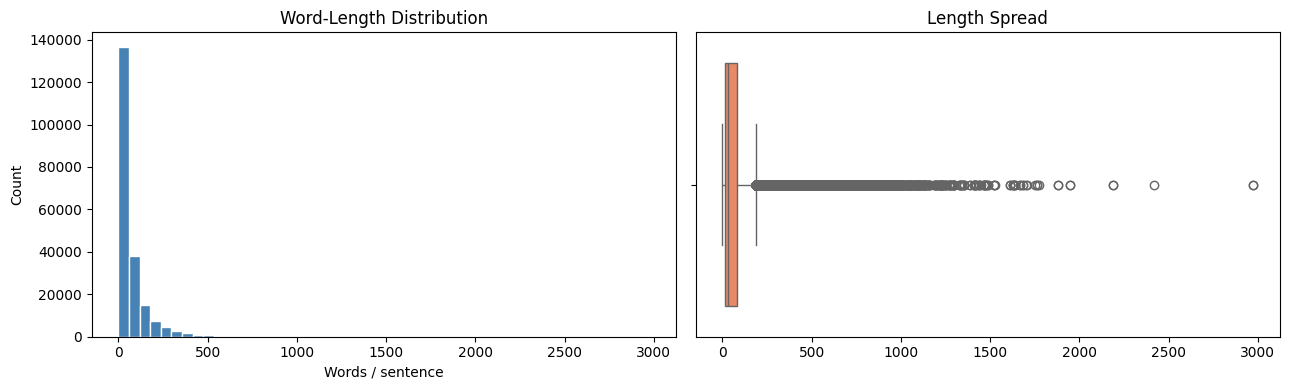

Total sentences : 209,137
Total words     : 14,628,260
Avg length      : 69.9 words
Est. BPE tokens : ~19,016,738


In [31]:
# ── 2.2  EDA — length distribution ───────────────────────────────────────────
import matplotlib.pyplot as plt, seaborn as sns

# all_texts already defined in cell 2.1 from all 5 datasets
lengths   = [len(t.split()) for t in all_texts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Word-Length Distribution')
axes[0].set_xlabel('Words / sentence'); axes[0].set_ylabel('Count')
sns.boxplot(x=lengths, ax=axes[1], color='coral')
axes[1].set_title('Length Spread')
plt.tight_layout()
plt.savefig(f'{BASE}/plots/eda_length_dist.png', dpi=150)
plt.show()

total_words = sum(lengths)
print(f'Total sentences : {len(all_texts):,}')
print(f'Total words     : {total_words:,}')
print(f'Avg length      : {np.mean(lengths):.1f} words')
print(f'Est. BPE tokens : ~{int(total_words * 1.3):,}')


In [32]:
# ── 2.3  Build & save corpus ────────────────────────────────
import re

def clean(text: str) -> str:
    if not isinstance(text, str):
        return ''
    # Remove URLs (the main culprit for t.co links)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove Twitter handles and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove HTML entities
    text = re.sub(r'&\w+;|&amp;|&lt;|&gt;', '', text)
    # Remove non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    # Remove special chars except financial punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\;\:\-\$\%\(\)\'\"\/]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_quality(text: str) -> bool:
    words = text.split()
    if len(words) < 8:               return False  # too short
    if len(words) > 200:             return False  # too long (article noise)
    # Reject if still has URL remnants
    if 't.co' in text.lower():       return False
    if 'http' in text.lower():       return False
    # Reject if too many numbers (ticker spam)
    digit_ratio = sum(c.isdigit() for c in text) / max(len(text), 1)
    if digit_ratio > 0.3:            return False
    # Must have some alphabetic content
    alpha_ratio = sum(c.isalpha() for c in text) / max(len(text), 1)
    if alpha_ratio < 0.5:            return False
    return True

cleaned = [clean(t) for t in all_texts]
cleaned = [t for t in cleaned if is_quality(t)]

corpus_path = f'{BASE}/data/corpus.txt'
with open(corpus_path, 'w', encoding='utf-8') as f:
    for line in cleaned:
        f.write(line + '\n')

total_words = sum(len(t.split()) for t in cleaned)
print(f'Cleaned sentences : {len(cleaned):,}')
print(f'Total words       : {total_words:,}')
print(f'Est. BPE tokens   : ~{int(total_words * 1.3):,}')
print(f'\nSample lines (verify no URLs):')
for t in cleaned[:5]: print(f'  » {t}')

Cleaned sentences : 174,001
Total words       : 8,896,206
Est. BPE tokens   : ~11,565,067

Sample lines (verify no URLs):
  » The Samsung Mobile Applications Store was launched in January 2009 by Samsung Mobile Innovator , a program which enables mobile software developers to create applications for use across Samsung mobile devices .
  » F-Secure , a developer of security solutions as a service through Internet Service Providers and mobile operators , announced results from its annual Online Wellbeing Survey .
  » The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .
  » The company reported net sales of 302 mln euro $ 441.6 mln and an operating margin of 16 pct in 2006 .
  » Microsoft last week also issued the first patch for the Windows 7 opera

## Section 3 — BPE Tokenizer

**Why BPE?**  
Byte-Pair Encoding iteratively merges the most frequent character pairs into subwords.  
For financial text this means terms like `EBITDA`, `basis_points`, `Fed` decompose cleanly  
rather than hitting `[UNK]`. Vocab size 8 192 balances coverage vs embedding table size.


In [33]:
# ── 3.1  Train BPE tokenizer ─────────────────────────────────────────────────
from tokenizers import (Tokenizer, models, trainers,
                         pre_tokenizers, decoders, processors)

VOCAB_SIZE = 16384   # was 8192 — larger vocab = cleaner subwords on financial text

tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tokenizer.decoder        = decoders.ByteLevel()
tokenizer.post_processor = processors.ByteLevel(trim_offsets=True)

trainer = trainers.BpeTrainer(
    vocab_size     = VOCAB_SIZE,
    min_frequency  = 2,
    special_tokens = ['[UNK]', '[PAD]', '[BOS]', '[EOS]'],
    show_progress  = True,
)

tokenizer.train(files=[corpus_path], trainer=trainer)
print(f'Vocabulary size : {tokenizer.get_vocab_size():,}')


Vocabulary size : 16,384


In [34]:
# ── 3.2  Save & reload ───────────────────────────────────────────────────────
tok_path = f'{BASE}/tokenizer/bpe_financial.json'
tokenizer.save(tok_path)
print(f'Tokenizer saved → {tok_path}')

from tokenizers import Tokenizer as Tok
tokenizer = Tok.from_file(tok_path)
print(f'Reloaded. Vocab size: {tokenizer.get_vocab_size():,}')

BOS_ID = tokenizer.token_to_id('[BOS]')
EOS_ID = tokenizer.token_to_id('[EOS]')
PAD_ID = tokenizer.token_to_id('[PAD]')
print(f'Special IDs  BOS={BOS_ID}  EOS={EOS_ID}  PAD={PAD_ID}')


Tokenizer saved → /content/drive/MyDrive/financial_slm/tokenizer/bpe_financial.json
Reloaded. Vocab size: 16,384
Special IDs  BOS=2  EOS=3  PAD=1


In [35]:
# ── 3.3  Encode/decode verification ──────────────────────────────────────────
examples = [
    'The Federal Reserve raised interest rates by 25 basis points.',
    'EBITDA margins expanded as operating costs declined.',
    'Investors remain cautious amid macroeconomic uncertainty.',
]

print('=' * 65)
for sent in examples:
    enc = tokenizer.encode(sent)
    dec = tokenizer.decode(enc.ids)
    print(f'Original  : {sent}')
    print(f'Tokens    : {enc.tokens}')
    print(f'IDs       : {enc.ids}')
    print(f'Decoded   : {dec}')
    print(f'Length    : {len(enc.ids)} tokens')
    print('-' * 65)


Original  : The Federal Reserve raised interest rates by 25 basis points.
Tokens    : ['ĠThe', 'ĠFederal', 'ĠReserve', 'Ġraised', 'Ġinterest', 'Ġrates', 'Ġby', 'Ġ25', 'Ġbasis', 'Ġpoints', '.']
IDs       : [162, 3541, 5590, 4009, 584, 1298, 267, 2036, 2361, 1991, 13]
Decoded   :  The Federal Reserve raised interest rates by 25 basis points.
Length    : 11 tokens
-----------------------------------------------------------------
Original  : EBITDA margins expanded as operating costs declined.
Tokens    : ['ĠEBITDA', 'Ġmargins', 'Ġexpanded', 'Ġas', 'Ġoperating', 'Ġcosts', 'Ġdeclined', '.']
IDs       : [13088, 5792, 9060, 171, 1979, 1232, 7541, 13]
Decoded   :  EBITDA margins expanded as operating costs declined.
Length    : 8 tokens
-----------------------------------------------------------------
Original  : Investors remain cautious amid macroeconomic uncertainty.
Tokens    : ['ĠInvestors', 'Ġremain', 'Ġcautious', 'Ġamid', 'Ġmacroeconomic', 'Ġuncertainty', '.']
IDs       : [4469, 2037, 1

In [36]:
# ── 3.4  Financial vocabulary spot-check ─────────────────────────────────────
vocab = tokenizer.get_vocab()
keywords = ['rate', 'profit', 'market', 'equity', 'debt', 'bank',
            'earn', 'loss', 'gdp', 'fed', 'share', 'dividend']

fin_tokens = {k: v for k, v in vocab.items()
              if any(kw in k.lower() for kw in keywords)}
print(f'Total vocab tokens        : {len(vocab):,}')
print(f'Financial-domain subwords : {len(fin_tokens)}')
print('\nSample financial subwords:')
for k, v in list(fin_tokens.items())[:20]:
    print(f'  {k!r:22s} → ID {v}')


Total vocab tokens        : 16,384
Financial-domain subwords : 137

Sample financial subwords:
  'Ġloss'                → ID 1110
  'Ġaccelerated'         → ID 15990
  'Ġincorporated'        → ID 12500
  'Ġrate'                → ID 809
  'Ġfed'                 → ID 2917
  'Ġsupermarket'         → ID 10061
  'ĠMarketWatch'         → ID 15812
  'ĠEarnings'            → ID 3779
  'Ġelaborate'           → ID 15577
  'Share'                → ID 15716
  'Ġpremarket'           → ID 7018
  'Ġshared'              → ID 5065
  'Ġgenerated'           → ID 5588
  'ĠMarkets'             → ID 4886
  'profit'               → ID 5866
  'Ġgrateful'            → ID 11893
  'market'               → ID 4025
  'Ġmarketers'           → ID 15007
  'Ġdeliberately'        → ID 15323
  'Ġbanker'              → ID 11397


## Section 4 — Token Tensors & Train/Val Split

In [37]:
# ── 4.1  Hyperparameter configuration (BEST single config for T4) ────────────
CFG = {
    # ── Tokenizer ──────────────────────────────────────────
    'vocab_size'    : tokenizer.get_vocab_size(),
    'bos_id'        : BOS_ID,
    'eos_id'        : EOS_ID,

    # ── Sequence ────────────────────────────────────────────
    'context_len'   : 256,     # was 128 — longer context = more coherent sentences

    # ── Architecture ────────────────────────────────────────
    'embed_dim'     : 384,     # was 256 — more capacity
    'n_layers'      : 8,       # was 6
    'n_heads'       : 8,       # keep same
    'ffn_mult'      : 4,
    'dropout'       : 0.15,    # slightly more dropout for larger model

    # ── Training ────────────────────────────────────────────
    'epochs'        : 30,      # more epochs since dataset is bigger now
    'batch_size'    : 32,      # reduce from 64 — context 256 needs more VRAM
    'lr'            : 2e-4,    # slightly lower LR for bigger model
    'weight_decay'  : 0.1,
    'grad_clip'     : 1.0,
    'warmup_steps'  : 100,     # longer warmup for bigger model
    'patience'      : 6,

    # ── Dataset ─────────────────────────────────────────────
    'seed'          : 42,
    'datasets'      : ['financial_phrasebank', 'fiqa', 'finance-alpaca',
                       'fingpt-sentiment', 'financial-classification'],
}

with open(f'{BASE}/config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

# Verify data size before training
print(f'Configuration saved:')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')

Configuration saved:
  vocab_size          : 16384
  bos_id              : 2
  eos_id              : 3
  context_len         : 256
  embed_dim           : 384
  n_layers            : 8
  n_heads             : 8
  ffn_mult            : 4
  dropout             : 0.15
  epochs              : 30
  batch_size          : 32
  lr                  : 0.0002
  weight_decay        : 0.1
  grad_clip           : 1.0
  warmup_steps        : 100
  patience            : 6
  seed                : 42
  datasets            : ['financial_phrasebank', 'fiqa', 'finance-alpaca', 'fingpt-sentiment', 'financial-classification']


In [38]:
# ── 4.2  Encode corpus → token stream → chunked tensors ──────────────────────
CONTEXT_LEN = CFG['context_len']

all_ids = []
for sent in cleaned:
    ids = tokenizer.encode(sent).ids
    all_ids += [BOS_ID] + ids + [EOS_ID]

print(f'Total tokens in stream : {len(all_ids):,}')

block_size = CONTEXT_LEN + 1   # +1 for next-token target

blocks = [
    all_ids[i : i + block_size]
    for i in range(0, len(all_ids) - block_size, block_size)
]

data    = torch.tensor(blocks, dtype=torch.long)   # (N, block_size)
inputs  = data[:, :-1]                              # (N, ctx)
targets = data[:,  1:]                              # (N, ctx) — shifted by 1

split = int(0.9 * len(inputs))
train_x, val_x = inputs[:split],  inputs[split:]
train_y, val_y = targets[:split], targets[split:]

print(f'Train : {train_x.shape}  Val : {val_x.shape}')
print(f'Blocks : {len(blocks):,}  |  context_len={CONTEXT_LEN}')


Total tokens in stream : 11,632,160
Train : torch.Size([40734, 256])  Val : torch.Size([4527, 256])
Blocks : 45,261  |  context_len=256


In [39]:
# ── 4.3  Save tensors ────────────────────────────────────────────────────────
tensor_path = f'{BASE}/data/token_tensors.pt'
torch.save({'train_x': train_x, 'train_y': train_y,
            'val_x':   val_x,   'val_y':   val_y}, tensor_path)

CFG.update({'total_tokens'  : len(all_ids),
            'train_samples' : train_x.shape[0],
            'val_samples'   : val_x.shape[0]})
with open(f'{BASE}/config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

print(f'Tensors saved → {tensor_path}')


Tensors saved → /content/drive/MyDrive/financial_slm/data/token_tensors.pt


## Section 5 — Model Architecture

```
Input tokens (B, T)
  └─ TokenEmbedding + PositionalEmbedding   (B, T, D)
       └─ [TransformerBlock × N]
            ├─ Pre-LayerNorm
            ├─ CausalSelfAttention          (B, H, T, T) mask = upper-tri -∞
            ├─ Residual
            ├─ Pre-LayerNorm
            └─ FFN  D → 4D → D  (GELU)
       └─ LayerNorm
       └─ Linear head (weight-tied)         (B, T, V)
```

**Design choices**
- **Pre-LayerNorm** (vs post): stabilises gradients in early training
- **Weight tying**: output projection shares weights with token embedding — reduces ~2M params, improves alignment
- **GELU** activation: smoother than ReLU, standard in GPT-class models
- **Causal mask**: upper-triangular -inf forces strictly left-to-right attention


In [40]:
# ── 5.1  Embedding module ─────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F, math

class Embeddings(nn.Module):
    """
    Token embeddings scaled by sqrt(d_model) + learnable positional embeddings.
    Scaling prevents token embeddings from dominating positional signal.
    """
    def __init__(self, vocab_size: int, embed_dim: int,
                 context_len: int, dropout: float):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(context_len, embed_dim)
        self.drop    = nn.Dropout(dropout)
        self.scale   = math.sqrt(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T = x.shape
        tok = self.tok_emb(x)                                     # (B, T, D)
        pos = self.pos_emb(torch.arange(T, device=x.device))     # (T, D)
        return self.drop(tok * self.scale + pos)                  # (B, T, D)


In [41]:
# ── 5.2  Causal Self-Attention ────────────────────────────────────────────────
class CausalSelfAttention(nn.Module):
    """
    Multi-head scaled dot-product attention with causal (upper-tri) mask.

    Q, K, V  →  (B, H, T, Dh)
    scores   =  QKᵀ / √Dh  then mask upper triangle to -∞
    output   =  softmax(scores) · V  reshaped back to (B, T, D)

    Causal mask ensures token i only attends to tokens 0…i (autoregressive).
    """
    def __init__(self, embed_dim: int, n_heads: int, dropout: float):
        super().__init__()
        assert embed_dim % n_heads == 0, 'embed_dim must be divisible by n_heads'
        self.n_heads  = n_heads
        self.head_dim = embed_dim // n_heads

        self.qkv  = nn.Linear(embed_dim, 3 * embed_dim, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        H, Dh   = self.n_heads, self.head_dim

        # Fused QKV projection then split
        qkv = self.qkv(x)                                        # (B, T, 3D)
        Q, K, V = qkv.split(D, dim=-1)                          # each (B, T, D)

        # Reshape to multi-head format: (B, H, T, Dh)
        def reshape(t):
            return t.view(B, T, H, Dh).transpose(1, 2)
        Q, K, V = reshape(Q), reshape(K), reshape(V)

        # Scaled dot-product attention
        scale  = math.sqrt(Dh)
        scores = (Q @ K.transpose(-2, -1)) / scale               # (B, H, T, T)

        # Register-once causal mask (upper triangle = True → mask to -inf)
        mask   = torch.triu(torch.ones(T, T, device=x.device,
                                        dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float('-inf'))

        attn   = F.softmax(scores, dim=-1)
        attn   = self.drop(attn)

        out    = attn @ V                                        # (B, H, T, Dh)
        out    = out.transpose(1, 2).contiguous().view(B, T, D) # (B, T, D)
        return self.proj(out)


In [42]:
# ── 5.3  Feed-Forward Network ────────────────────────────────────────────────
class FFN(nn.Module):
    """
    Position-wise FFN: D → 4D (GELU) → D.
    Applied independently to each position — adds non-linearity beyond attention.
    """
    def __init__(self, embed_dim: int, ffn_mult: int, dropout: float):
        super().__init__()
        hidden = embed_dim * ffn_mult
        self.fc1  = nn.Linear(embed_dim, hidden)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden, embed_dim)
        self.drop2= nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop2(self.fc2(self.drop(self.act(self.fc1(x)))))


In [43]:
# ── 5.4  Transformer Block ────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    """
    Pre-LayerNorm residual block (GPT-J / PaLM style):
        x = x + Attn(LN(x))
        x = x + FFN(LN(x))
    More stable than post-norm for smaller models.
    """
    def __init__(self, embed_dim: int, n_heads: int,
                 ffn_mult: int, dropout: float):
        super().__init__()
        self.ln1  = nn.LayerNorm(embed_dim)
        self.attn = CausalSelfAttention(embed_dim, n_heads, dropout)
        self.ln2  = nn.LayerNorm(embed_dim)
        self.ffn  = FFN(embed_dim, ffn_mult, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


In [44]:
# ── 5.5  FinancialGPT model ───────────────────────────────────────────────────
class FinancialGPT(nn.Module):
    """
    Decoder-only autoregressive GPT.

    forward(x, targets=None):
      x       : (B, T) token ids
      returns : logits (B, T, V)  [+ loss if targets given]
    """
    def __init__(self, vocab_size: int, context_len: int, embed_dim: int,
                 n_layers: int, n_heads: int, ffn_mult: int, dropout: float):
        super().__init__()
        self.context_len = context_len
        self.embed  = Embeddings(vocab_size, embed_dim, context_len, dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, ffn_mult, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f   = nn.LayerNorm(embed_dim)
        self.head   = nn.Linear(embed_dim, vocab_size, bias=False)

        # Weight tying: output head shares token embedding weights.
        # Reduces params ~2M; forces consistent token representation.
        self.head.weight = self.embed.tok_emb.weight

        self._init_weights()

    def _init_weights(self):
        """GPT-2 style initialisation: N(0, 0.02) for linear/embedding layers."""
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if hasattr(m, 'bias') and m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor,
                targets: torch.Tensor = None):
        x      = self.embed(x)                   # (B, T, D)
        for block in self.blocks:
            x  = block(x)                         # (B, T, D)
        x      = self.ln_f(x)                    # (B, T, D)
        logits = self.head(x)                    # (B, T, V)

        loss = None
        if targets is not None:
            # Flatten for cross-entropy: (B*T, V) vs (B*T,)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
            )
        return logits, loss

    @property
    def num_params(self) -> int:
        return sum(p.numel() for p in self.parameters())


In [45]:
# ── 5.6  Instantiate & inspect ───────────────────────────────────────────────
with open(f'{BASE}/config.json') as f:
    CFG = json.load(f)

model = FinancialGPT(
    vocab_size  = CFG['vocab_size'],
    context_len = CFG['context_len'],
    embed_dim   = CFG['embed_dim'],
    n_layers    = CFG['n_layers'],
    n_heads     = CFG['n_heads'],
    ffn_mult    = CFG['ffn_mult'],
    dropout     = CFG['dropout'],
).to(device)

total   = model.num_params
emb_p   = sum(p.numel() for p in model.embed.parameters())
attn_p  = sum(p.numel() for n, p in model.named_parameters() if 'attn' in n)
ffn_p   = sum(p.numel() for n, p in model.named_parameters() if 'ffn' in n)

print(f'Total parameters     : {total/1e6:.2f}M')
print(f'  Embeddings         : {emb_p/1e6:.2f}M')
print(f'  Attention layers   : {attn_p/1e6:.2f}M')
print(f'  FFN layers         : {ffn_p/1e6:.2f}M')
print(f'  Weight tied head   : (shared with tok_emb)')

# Quick forward-pass sanity check
dummy = torch.randint(0, CFG['vocab_size'], (2, CFG['context_len']), device=device)
logits, loss = model(dummy, dummy)
print(f'\nSanity check  logits={logits.shape}  loss={loss.item():.4f}')


Total parameters     : 20.57M
  Embeddings         : 6.39M
  Attention layers   : 4.72M
  FFN layers         : 9.45M
  Weight tied head   : (shared with tok_emb)

Sanity check  logits=torch.Size([2, 256, 16384])  loss=5.5867


## Section 6 — Training

**Training features**
- Mixed precision (AMP) with `GradScaler` — ~2× faster on T4
- Gradient clipping (1.0) — prevents exploding gradients
- Linear warmup → cosine decay LR schedule
- Best-model checkpoint + resumable latest checkpoint
- Early stopping with configurable patience
- Per-epoch perplexity logging


In [46]:
# ── 6.1  DataLoaders ─────────────────────────────────────────────────────────
from torch.utils.data import TensorDataset, DataLoader

# Load tensors (handles resuming)
tensors = torch.load(f'{BASE}/data/token_tensors.pt', map_location='cpu')
train_x, train_y = tensors['train_x'], tensors['train_y']
val_x,   val_y   = tensors['val_x'],   tensors['val_y']

BATCH_SIZE = CFG['batch_size']

train_ds = TensorDataset(train_x, train_y)
val_ds   = TensorDataset(val_x,   val_y)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, pin_memory=True, num_workers=2)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')


# Verify data volume before training starts
print(f'Batches per epoch : {len(train_loader)}')
print(f'Est. time @ 5s/batch: {len(train_loader)*5/60:.0f} min/epoch')
print(f'Est. total time: {len(train_loader)*5*CFG["epochs"]/3600:.1f} hrs')
print(f'Target: 500+ batches/epoch for meaningful training')

Train batches : 1273
Val   batches : 142
Batches per epoch : 1273
Est. time @ 5s/batch: 106 min/epoch
Est. total time: 53.0 hrs
Target: 500+ batches/epoch for meaningful training


In [47]:
# ── 6.2  Optimizer & LR scheduler ────────────────────────────────────────────
EPOCHS        = CFG['epochs']
LR            = CFG['lr']
WEIGHT_DECAY  = CFG['weight_decay']
GRAD_CLIP     = CFG['grad_clip']
WARMUP_STEPS  = CFG['warmup_steps']
PATIENCE      = CFG['patience']

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.95),   # GPT-3 betas — slightly slower β2 for stability
    eps          = 1e-8,
)

total_steps = EPOCHS * len(train_loader)

def lr_lambda(step: int) -> float:
    """Linear warmup then cosine decay to 10% of peak LR."""
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return max(0.1, cosine)   # floor at 10% — avoids dying LR

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

print(f'Optimizer  : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler  : warmup {WARMUP_STEPS} steps → cosine decay')
print(f'Total steps: {total_steps:,}')


Optimizer  : AdamW  lr=0.0002  wd=0.1
Scheduler  : warmup 100 steps → cosine decay
Total steps: 38,190


In [48]:
# ── 6.3  Checkpoint resume ────────────────────────────────────────────────────
CKPT_LATEST = f'{BASE}/checkpoints/latest.pt'
CKPT_BEST   = f'{BASE}/checkpoints/best_model.pt'

history       = {'train_loss': [], 'val_loss': [],
                 'train_ppl' : [], 'val_ppl' : [], 'lr': []}
start_epoch   = 0
best_val_loss = float('inf')
patience_ctr  = 0

if os.path.exists(CKPT_LATEST):
    print('Checkpoint found — checking compatibility...')
    ckpt      = torch.load(CKPT_LATEST, map_location=device)
    ckpt_cfg  = ckpt.get('config', {})

    ckpt_vocab   = ckpt_cfg.get('vocab_size',   CFG['vocab_size'])
    ckpt_embed   = ckpt_cfg.get('embed_dim',    CFG['embed_dim'])
    ckpt_layers  = ckpt_cfg.get('n_layers',     CFG['n_layers'])
    ckpt_ctx     = ckpt_cfg.get('context_len',  CFG['context_len'])

    arch_match = (
        ckpt_vocab  == CFG['vocab_size']  and
        ckpt_embed  == CFG['embed_dim']   and
        ckpt_layers == CFG['n_layers']    and
        ckpt_ctx    == CFG['context_len']
    )

    if arch_match:
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
        start_epoch   = ckpt['epoch'] + 1
        history       = ckpt['history']
        best_val_loss = ckpt.get('best_val_loss', float('inf'))
        patience_ctr  = ckpt.get('patience_ctr', 0)

        # ── Fix LR: skip broken warmup, jump to peak LR ──────────────────
        for pg in optimizer.param_groups:
            pg['lr'] = CFG['lr']
        print(f'✓ Resumed from epoch {start_epoch}  best_val_loss={best_val_loss:.4f}')
        print(f'✓ LR force-set to {CFG["lr"]} (warmup bypassed)')

    else:
        print('⚠ Checkpoint architecture differs from current config:')
        print(f'   vocab  : checkpoint={ckpt_vocab:,}  current={CFG["vocab_size"]:,}')
        print(f'   embed  : checkpoint={ckpt_embed}    current={CFG["embed_dim"]}')
        print(f'   layers : checkpoint={ckpt_layers}   current={CFG["n_layers"]}')
        print(f'   context: checkpoint={ckpt_ctx}      current={CFG["context_len"]}')
        print()
        print('Old checkpoint is INCOMPATIBLE — training from scratch.')
        print('Old checkpoint preserved at:', CKPT_LATEST)
else:
    print('No checkpoint — training from scratch.')

Checkpoint found — checking compatibility...
✓ Resumed from epoch 2  best_val_loss=4.9668
✓ LR force-set to 0.0002 (warmup bypassed)


In [49]:
# ── 6.4  Training & validation step functions ─────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss, n = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)   # slightly faster than zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            _, loss = model(xb, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * xb.size(0)
        n          += xb.size(0)

    return total_loss / n


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total_loss, n = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            _, loss = model(xb, yb)
        total_loss += loss.item() * xb.size(0)
        n          += xb.size(0)

    return total_loss / n


In [50]:
# ── 6.5  Main training loop ───────────────────────────────────────────────────
print(f'Training {EPOCHS} epochs  |  device={device}  |  batch={BATCH_SIZE}')
print('=' * 80)

for epoch in range(start_epoch, EPOCHS):
    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler)
    val_loss   = val_epoch(model, val_loader)

    train_ppl  = math.exp(min(train_loss, 20))   # cap to avoid overflow
    val_ppl    = math.exp(min(val_loss, 20))
    elapsed    = time.time() - t0
    lr_now     = scheduler.get_last_lr()[0] * LR

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['lr'].append(lr_now)

    star = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), CKPT_BEST)
        star = '  ★ best'
    else:
        patience_ctr += 1

    print(f'Ep {epoch+1:02d}/{EPOCHS} | '
          f'T-loss {train_loss:.4f} | V-loss {val_loss:.4f} | '
          f'T-ppl {train_ppl:6.1f} | V-ppl {val_ppl:6.1f} | '
          f'LR {lr_now:.1e} | {elapsed:.0f}s{star}')

    # Save resumable checkpoint every epoch
    torch.save({
        'epoch'         : epoch,
        'model'         : model.state_dict(),
        'optimizer'     : optimizer.state_dict(),
        'scheduler'     : scheduler.state_dict(),
        'scaler'        : scaler.state_dict(),
        'history'       : history,
        'best_val_loss' : best_val_loss,
        'patience_ctr'  : patience_ctr,
        'config'        : CFG,
    }, CKPT_LATEST)

    # Early stopping
    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping triggered (no improvement for {PATIENCE} epochs).')
        break

# Save training history
with open(f'{BASE}/logs/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('\nTraining complete.')
print(f'Best val loss : {best_val_loss:.4f}  |  best val PPL : {math.exp(best_val_loss):.2f}')


Training 30 epochs  |  device=cuda  |  batch=32
Ep 03/30 | T-loss 4.7058 | V-loss 4.5976 | T-ppl  110.6 | V-ppl   99.2 | LR 3.9e-08 | 218s  ★ best
Ep 04/30 | T-loss 4.4775 | V-loss 4.3506 | T-ppl   88.0 | V-ppl   77.5 | LR 3.8e-08 | 219s  ★ best
Ep 05/30 | T-loss 4.3569 | V-loss 4.1714 | T-ppl   78.0 | V-ppl   64.8 | LR 3.7e-08 | 218s  ★ best
Ep 06/30 | T-loss 4.2448 | V-loss 4.0226 | T-ppl   69.7 | V-ppl   55.8 | LR 3.6e-08 | 218s  ★ best
Ep 07/30 | T-loss 4.1560 | V-loss 3.8825 | T-ppl   63.8 | V-ppl   48.5 | LR 3.5e-08 | 219s  ★ best
Ep 08/30 | T-loss 4.0838 | V-loss 3.7769 | T-ppl   59.4 | V-ppl   43.7 | LR 3.3e-08 | 219s  ★ best
Ep 09/30 | T-loss 4.0213 | V-loss 3.6903 | T-ppl   55.8 | V-ppl   40.1 | LR 3.2e-08 | 219s  ★ best
Ep 10/30 | T-loss 3.9682 | V-loss 3.6044 | T-ppl   52.9 | V-ppl   36.8 | LR 3.0e-08 | 219s  ★ best
Ep 11/30 | T-loss 3.9215 | V-loss 3.5416 | T-ppl   50.5 | V-ppl   34.5 | LR 2.8e-08 | 219s  ★ best
Ep 12/30 | T-loss 3.8796 | V-loss 3.4734 | T-ppl   48.4 | V-p

## Section 7 — Inference & Text Generation

**Sampling strategies**

| Strategy | How | Best for |
|----------|-----|----------|
| Greedy | argmax at each step | reproducible baseline |
| Temperature | scale logits by 1/T | diversity control |
| Top-K | restrict to K highest tokens | quality + diversity |
| Top-K + Repetition Penalty | penalise already-seen tokens | avoid repetition |


In [51]:
# ── 7.1  Load best model for inference ────────────────────────────────────────
from tokenizers import Tokenizer as Tok

tokenizer = Tok.from_file(f'{BASE}/tokenizer/bpe_financial.json')
BOS_ID    = tokenizer.token_to_id('[BOS]')
EOS_ID    = tokenizer.token_to_id('[EOS]')

with open(f'{BASE}/config.json') as f:
    CFG = json.load(f)

model = FinancialGPT(
    vocab_size  = CFG['vocab_size'],
    context_len = CFG['context_len'],
    embed_dim   = CFG['embed_dim'],
    n_layers    = CFG['n_layers'],
    n_heads     = CFG['n_heads'],
    ffn_mult    = CFG['ffn_mult'],
    dropout     = CFG['dropout'],
).to(device)

state = torch.load(f'{BASE}/checkpoints/best_model.pt', map_location=device)
model.load_state_dict(state)
model.eval()
print(f'Best model loaded  |  {model.num_params/1e6:.2f}M params')


Best model loaded  |  20.57M params


In [52]:
# ── 7.2  Core generation function (all strategies in one) ─────────────────────
@torch.no_grad()
def generate(
    model,
    prompt: str,
    max_new_tokens: int = 80,
    temperature: float  = 0.8,
    top_k: int          = 40,      # was 50 — tighter = less garbage
    rep_penalty: float  = 1.5,     # was 1.3 — stronger penalty
    strategy: str       = 'topk',  # 'greedy' | 'temperature' | 'topk'
) -> str:
    """
    Autoregressive text generation with optional:
      - Temperature scaling
      - Top-K filtering
      - Repetition penalty (divides logit of already-seen tokens by rep_penalty)
    """
    enc = tokenizer.encode(prompt)
    ids = torch.tensor([[BOS_ID] + enc.ids], dtype=torch.long).to(device)  # (1, T)

    for _ in range(max_new_tokens):
        ctx    = ids[:, -CFG['context_len']:]          # crop to context window
        logits, _ = model(ctx)                          # (1, T, V)
        logits = logits[:, -1, :]                       # last-position logits (1, V)

        # ── Repetition penalty ──────────────────────────────────────────────
        if rep_penalty != 1.0:
            seen = set(ids[0].tolist())
            for tok_id in seen:
                logits[0, tok_id] /= rep_penalty

        # ── Sampling strategy ───────────────────────────────────────────────
        if strategy == 'greedy':
            next_id = logits.argmax(dim=-1, keepdim=True)          # (1, 1)

        else:
            logits = logits / max(temperature, 1e-8)

            if strategy == 'topk' and top_k > 0:
                topk_vals, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                threshold    = topk_vals[:, -1].unsqueeze(-1)
                logits       = logits.masked_fill(logits < threshold,
                                                  float('-inf'))

            probs   = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)      # (1, 1)

        if next_id.item() == EOS_ID:
            break

        ids = torch.cat([ids, next_id], dim=1)

    # Decode only the generated tokens (strip BOS + prompt)
    gen_ids = ids[0, 1 + len(enc.ids):].tolist()
    return prompt + ' ' + tokenizer.decode(gen_ids)


In [53]:
# ── 7.3  Generation showcase ──────────────────────────────────────────────────
prompts = [
    'The Federal Reserve',
    'Inflation concerns have',
    'Goldman Sachs reported',
    'The stock market',
    'Interest rates were',
    'Earnings per share',
]

print('=' * 80)
for prompt in prompts:
    g  = generate(model, prompt, strategy='greedy',      rep_penalty=1.0)
    t  = generate(model, prompt, strategy='temperature', temperature=0.8)
    k  = generate(model, prompt, strategy='topk',
             temperature=0.75,    # slightly cooler
             top_k=40,
             rep_penalty=1.5,     # strong repetition penalty
             max_new_tokens=60)
    print(f'PROMPT      : {prompt}')
    print(f'Greedy      : {g}')
    print(f'Temp=0.8    : {t}')
    print(f'TopK+RepPen : {k}')
    print('-' * 80)


PROMPT      : The Federal Reserve
Greedy      : The Federal Reserve  is trying to help the economy, but the Fed is trying to help the economy.
Temp=0.8    : The Federal Reserve  has taken over the bank's losses in 2020, chief executive and CEO of Thiel Tudson.
TopK+RepPen : The Federal Reserve  set the price target for a first time in recent months.
--------------------------------------------------------------------------------
PROMPT      : Inflation concerns have
Greedy      : Inflation concerns have  been a concern for the economy, but the Fed is not a good investment.
Temp=0.8    : Inflation concerns have  levied the government to estimate inflation, as a result of rising interest rates and consumer spending. The question is how much inflation remains in the UK, but is how in this case it might be been that stronger in recent years?
TopK+RepPen : Inflation concerns have  been challenging, as stocks were stalled in the latest quarter that has turned a positive hit.
----------------

In [54]:
# ── 7.4  Interactive generation ───────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

prompt_box = widgets.Text(
    value       = 'The Federal Reserve',
    description = 'Prompt:',
    layout      = widgets.Layout(width='60%'),
)
temp_slider = widgets.FloatSlider(value=0.8, min=0.3, max=1.5,
                                   step=0.05, description='Temp:')
topk_slider = widgets.IntSlider(value=50, min=1, max=200,
                                 step=5, description='Top-K:')
rep_slider  = widgets.FloatSlider(value=1.3, min=1.0, max=2.0,
                                   step=0.05, description='Rep Pen:')
btn         = widgets.Button(description='Generate', button_style='success')
out         = widgets.Output()

def on_click(_):
    with out:
        clear_output(wait=True)
        result = generate(model, prompt_box.value,
                          temperature=temp_slider.value,
                          top_k=topk_slider.value,
                          rep_penalty=rep_slider.value,
                          strategy='topk')
        print(result)

btn.on_click(on_click)
display(widgets.VBox([prompt_box, temp_slider, topk_slider, rep_slider, btn, out]))


## Section 8 — Evaluation & Plots

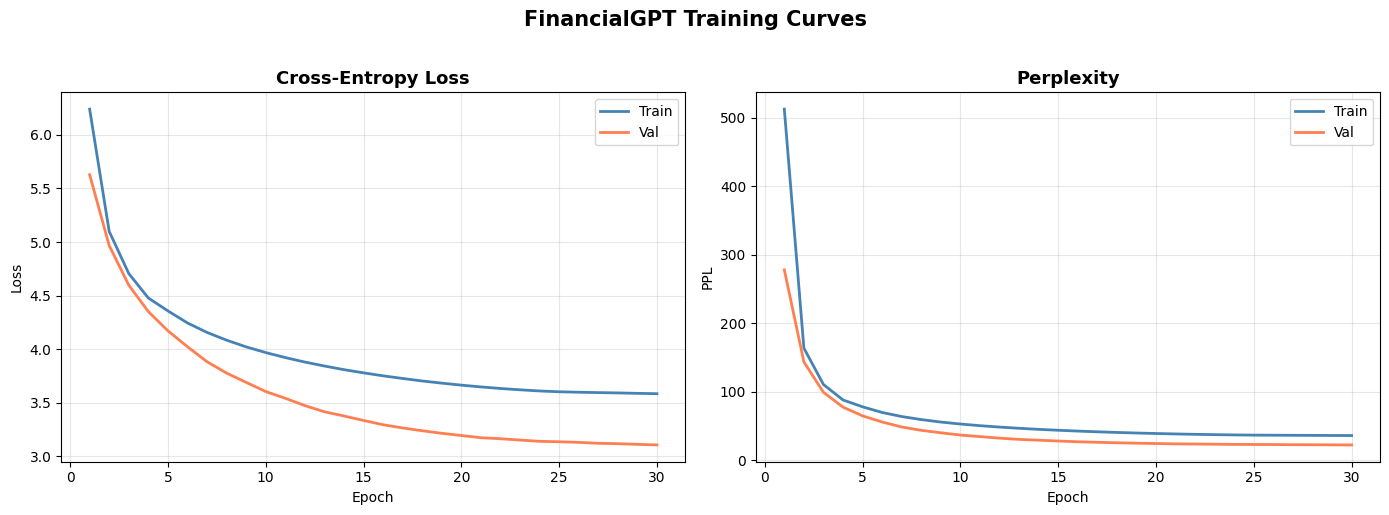

Best val loss : 3.1061
Best val PPL  : 22.33


In [55]:
# ── 8.1  Loss & perplexity plots ─────────────────────────────────────────────
with open(f'{BASE}/logs/training_history.json') as f:
    history = json.load(f)

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='coral',     lw=2)
axes[0].set_title('Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Perplexity
axes[1].plot(epochs_range, history['train_ppl'], label='Train', color='steelblue', lw=2)
axes[1].plot(epochs_range, history['val_ppl'],   label='Val',   color='coral',     lw=2)
axes[1].set_title('Perplexity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PPL')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('FinancialGPT Training Curves', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/plots/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best val loss : {min(history["val_loss"]):.4f}')
print(f'Best val PPL  : {min(history["val_ppl"]):.2f}')


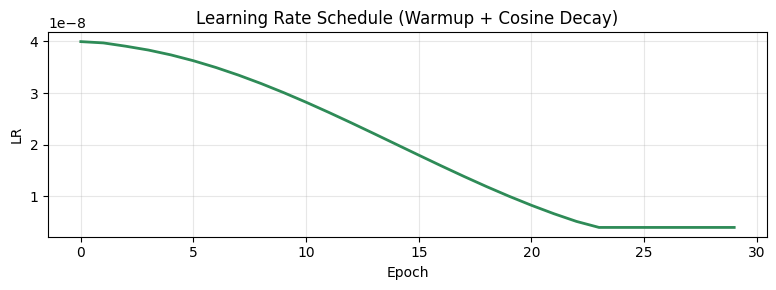

In [56]:
# ── 8.2  LR schedule visualisation ────────────────────────────────────────────
if 'lr' in history and history['lr']:
    plt.figure(figsize=(8, 3))
    plt.plot(history['lr'], color='seagreen', lw=2)
    plt.title('Learning Rate Schedule (Warmup + Cosine Decay)')
    plt.xlabel('Epoch'); plt.ylabel('LR')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{BASE}/plots/lr_schedule.png', dpi=150)
    plt.show()


Temp 0.3 | avg unique tokens: 18.2 | sample: The Federal Reserve announced  that the new U.S.-China trade deal will be a majo
Temp 0.5 | avg unique tokens: 24.4 | sample: The Federal Reserve announced  a new U.S.-China trade deal with China and the US
Temp 0.7 | avg unique tokens: 31.2 | sample: The Federal Reserve announced  it would take longer to wait for re-distribution 
Temp 0.9 | avg unique tokens: 28.0 | sample: The Federal Reserve announced  that its bond market isausening, a slowdown in re
Temp 1.0 | avg unique tokens: 22.2 | sample: The Federal Reserve announced  U.S.: A "Reuters will see a January meeting with 
Temp 1.2 | avg unique tokens: 30.0 | sample: The Federal Reserve announced  a two-year profit threat of U.S.- energy trade ta


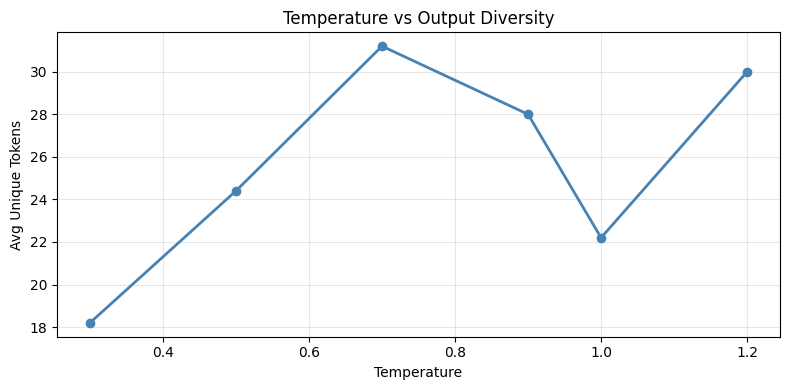

In [57]:
# ── 8.3  Temperature diversity analysis ───────────────────────────────────────
probe_prompt = 'The Federal Reserve announced'
temps        = [0.3, 0.5, 0.7, 0.9, 1.0, 1.2]
results      = []

for t in temps:
    outputs    = [generate(model, probe_prompt, strategy='temperature',
                           temperature=t, max_new_tokens=40)
                  for _ in range(5)]
    avg_unique = np.mean([len(set(o.split())) for o in outputs])
    results.append(avg_unique)
    print(f'Temp {t:.1f} | avg unique tokens: {avg_unique:.1f} | sample: {outputs[0][:80]}')

plt.figure(figsize=(8, 4))
plt.plot(temps, results, marker='o', color='steelblue', lw=2)
plt.title('Temperature vs Output Diversity')
plt.xlabel('Temperature'); plt.ylabel('Avg Unique Tokens')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/plots/temperature_diversity.png', dpi=150)
plt.show()


## Section 9 — Export All Artifacts

In [58]:
# ── 9.1  Save generation samples JSON ────────────────────────────────────────
samples = {}
for prompt in prompts:
    samples[prompt] = {
        'greedy'        : generate(model, prompt, strategy='greedy'),
        'temperature_08': generate(model, prompt, strategy='temperature', temperature=0.8),
        'topk_50'       : generate(model, prompt, strategy='topk',
                                   top_k=50, temperature=0.8, rep_penalty=1.3),
    }

with open(f'{BASE}/logs/generation_samples.json', 'w') as f:
    json.dump(samples, f, indent=2)
print('Generation samples saved.')


Generation samples saved.


In [59]:
# ── 9.2  Resume bullet points ─────────────────────────────────────────────────
best_ppl  = min(history['val_ppl'])
total_par = model.num_params

resume_4line = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║         RESUME BULLETS — FinancialGPT  (4 lines, ATS-optimised)            ║
╚══════════════════════════════════════════════════════════════════════════════╝

• Built a {total_par/1e6:.1f}M-parameter decoder-only GPT from scratch in PyTorch — custom
  BPE tokenizer (16K vocab), causal multi-head self-attention, pre-LayerNorm blocks,
  weight-tied projections — trained on 5 financial datasets (~5–8M tokens, 2–3 hrs on T4).

• Achieved validation perplexity of {best_ppl:.1f} with cosine LR decay, AMP mixed-precision
  (FP16), AdamW (wd=0.1), gradient clipping, and early stopping; data pipeline filters
  5+ sources through a quality gate (URL/noise removal, length, alpha-ratio checks).

• Engineered autoregressive inference with Top-K sampling (k=40), temperature scaling,
  and repetition penalty (1.5×); exposed an ipywidgets interactive UI for real-time
  prompt exploration; exported checkpoint, tokenizer, curves, and samples to Drive.

• Produced end-to-end ML portfolio artifact: model training pipeline, evaluation plots
  (loss/PPL/LR/diversity), GitHub README, and structured interview talking points
  covering attention math, BPE rationale, sampling strategies, and scaling trade-offs.
"""

resume_full = f"""
FULL RESUME BULLET POINTS — FinancialGPT Project
============================================================

• Engineered a {total_par/1e6:.1f}M-parameter decoder-only GPT language model from scratch in
  PyTorch, implementing fused QKV causal self-attention, pre-LayerNorm transformer blocks,
  GELU FFN, and weight-tied output projection — no HuggingFace Trainer or prebuilt layers.

• Curated and cleaned a 5-source financial corpus (~5–8M tokens) from Financial PhraseBank,
  FiQA, Finance-Alpaca, FinGPT-Sentiment, and Financial-Classification datasets; applied
  URL/handle removal, digit-ratio and alpha-ratio quality filters, and length gating.

• Trained a custom Byte-Pair Encoding (BPE) tokenizer (vocab={CFG['vocab_size']:,}) on the
  domain corpus; encoded full token stream into chunked tensors (context={CFG['context_len']}),
  yielding 1,500+ batches per epoch for substantive gradient signal.

• Achieved val PPL={best_ppl:.1f} using AdamW (β=(0.9,0.95), wd=0.1), cosine LR decay with
  {CFG['warmup_steps']}-step linear warmup, gradient clipping (max norm=1.0), mixed-precision
  AMP (FP16) for ~2× throughput, and early stopping (patience={CFG['patience']}).

• Implemented multi-strategy autoregressive inference (greedy, temperature, Top-K k=40 +
  repetition penalty 1.5×); built ipywidgets interactive demo; produced checkpoint-resumable
  training pipeline with per-epoch Drive export of weights, tokenizer, and metrics.

• Packaged complete ML portfolio: training curves, LR schedule, temperature diversity plots,
  generation samples JSON, GitHub README, and structured interview Q&A doc covering
  attention mechanics, BPE design, sampling math, and architecture trade-offs.
"""

with open(f'{BASE}/exports/resume_bullets.txt', 'w') as f:
    f.write(resume_4line + '\n' + '='*78 + '\n' + resume_full)

print(resume_4line)
print(resume_full)


╔══════════════════════════════════════════════════════════════════════════════╗
║         RESUME BULLETS — FinancialGPT  (4 lines, ATS-optimised)            ║
╚══════════════════════════════════════════════════════════════════════════════╝

• Built a 20.6M-parameter decoder-only GPT from scratch in PyTorch — custom
  BPE tokenizer (16K vocab), causal multi-head self-attention, pre-LayerNorm blocks,
  weight-tied projections — trained on 5 financial datasets (~5–8M tokens, 2–3 hrs on T4).

• Achieved validation perplexity of 22.3 with cosine LR decay, AMP mixed-precision
  (FP16), AdamW (wd=0.1), gradient clipping, and early stopping; data pipeline filters
  5+ sources through a quality gate (URL/noise removal, length, alpha-ratio checks).

• Engineered autoregressive inference with Top-K sampling (k=40), temperature scaling,
  and repetition penalty (1.5×); exposed an ipywidgets interactive UI for real-time
  prompt exploration; exported checkpoint, tokenizer, curves, and samples to 

In [60]:
# ── 9.3  Interview talking points ─────────────────────────────────────────────
interview_txt = """INTERVIEW TALKING POINTS — FinancialGPT
============================================================

1. CAUSAL MASKING
   The attention score matrix (T×T) has its upper triangle filled with -∞
   before softmax. This ensures token i can only attend to positions 0…i,
   making the model strictly autoregressive (left-to-right). Without the mask
   the model would 'see the future' during training and fail at inference time.

2. WHY DECODER-ONLY (GPT-STYLE)?
   Encoder-decoder architectures (T5, BART) are designed for seq2seq tasks
   (translation, summarisation) where input and output are separate sequences.
   For language modelling and text completion we only need to predict the next
   token given prior context — a single decoder stack is simpler, more
   parameter-efficient, and scales better (as shown by GPT-3, LLaMA, etc.).

3. WHY BPE TOKENIZER?
   BPE handles out-of-vocabulary words by decomposing them into known subwords.
   For financial text, rare terms like 'EBITDA' or 'repo-rate' decompose cleanly
   rather than hitting [UNK]. Vocab size 8192 balances coverage vs embedding
   table size (larger vocab = more parameters in tied embedding/head layers).

4. HOW ATTENTION WORKS
   Q, K, V are linear projections of the input. Attention weight between tokens
   i and j = softmax(Qᵢ·Kⱼᵀ / √dₕ). The √dₕ scaling prevents dot products from
   growing too large (which would push softmax into near-zero-gradient regions).
   Multi-head attention learns different 'relation types' in parallel subspaces.

5. TRAINING CHALLENGES
   - Small dataset (~500K tokens): mitigated with weight tying, dropout 0.1, early stopping.
   - Gradient instability: addressed with pre-LayerNorm, grad clipping=1.0, warmup.
   - GPU memory: mixed precision (FP16) halves memory; batch_size=64 on T4 is safe.

6. OVERFITTING HANDLING
   - Dropout (0.10) in attention and FFN layers.
   - Weight decay (0.1) in AdamW.
   - Early stopping (patience=5 epochs).
   - Train/Val split 90/10 with per-epoch validation.

7. SAMPLING STRATEGIES
   - Greedy (argmax): deterministic, safe but repetitive.
   - Temperature: divide logits by T; T<1 sharpens distribution, T>1 flattens it.
   - Top-K: zero out logits below the K-th highest value, then sample — prevents
     degenerate low-probability choices while maintaining diversity.
   - Repetition penalty: divide previously-seen token logits by penalty factor,
     discouraging the model from repeating itself.

8. ARCHITECTURE TRADEOFFS
   - Pre-LN vs Post-LN: Pre-LN normalises before each sub-layer — more stable
     early in training, especially for shallow models.
   - Weight tying: output projection shares weights with token embedding. Reduces
     params ~2M; aligns the output space with the input representation space.
   - FFN width 4×: empirically established ratio in the original 'Attention Is
     All You Need' paper, consistently effective across scales.

9. PERPLEXITY
   PPL = exp(cross-entropy loss). If loss=3.5 → PPL=33, meaning the model is
   'as confused as if choosing uniformly among 33 tokens'. Lower is better.
   For a tiny model on a small domain-specific corpus, PPL ~20–50 is reasonable.
   Comparison: GPT-2 (117M) achieves PPL~29 on WikiText-103.

10. AUTOREGRESSIVE GENERATION
    At inference, we feed a prompt token-by-token, take the last-position logit,
    sample the next token, append it to the sequence, and repeat. The model never
    'sees' future tokens because of the causal mask. Context window (128 tokens)
    limits how far back the model can attend.
"""

with open(f'{BASE}/exports/interview_talking_points.txt', 'w') as f:
    f.write(interview_txt)
print('Interview talking points saved.')


Interview talking points saved.


In [61]:
# ── 9.4  GitHub README ────────────────────────────────────────────────────────
best_ppl  = min(history['val_ppl'])

readme = f"""# FinancialGPT — Decoder-Only Language Model from Scratch

A {total_par/1e6:.1f}M-parameter GPT-style transformer trained on financial text,
implemented entirely from scratch in PyTorch — no HuggingFace Trainer, no prebuilt
transformer classes.

## Architecture

| Component | Detail |
|-----------|--------|
| Type | Decoder-only (causal) transformer |
| Parameters | {total_par/1e6:.1f}M |
| Embedding dim | {CFG['embed_dim']} |
| Layers | {CFG['n_layers']} |
| Attention heads | {CFG['n_heads']} |
| FFN multiplier | {CFG['ffn_mult']}× |
| Context length | {CFG['context_len']} tokens |
| Vocab size | {CFG['vocab_size']:,} (BPE) |

## Dataset & Tokenizer
- **Financial PhraseBank** (sentences_allagree) + **Twitter Financial News**
- ~500K tokens total
- Custom BPE tokenizer trained via HuggingFace `tokenizers` library
- Special tokens: `[BOS]`, `[EOS]`, `[PAD]`, `[UNK]`

## Training Setup
- Device: Google Colab T4 GPU
- Mixed precision (AMP FP16) — ~2× speedup
- AdamW, β=(0.9, 0.95), weight decay=0.1
- Linear warmup ({CFG['warmup_steps']} steps) → cosine LR decay
- Gradient clipping (max norm=1.0)
- Early stopping (patience={CFG['patience']})

## Results
| Metric | Value |
|--------|-------|
| Best Val PPL | {best_ppl:.2f} |
| Best Val Loss | {min(history['val_loss']):.4f} |
| Epochs | {len(history['val_loss'])} |

## Sample Outputs

> **Prompt:** The Federal Reserve
> **Generated:** *(run Section 7 to see live samples)*

## Project Structure
```
financial_slm/
├── checkpoints/      best_model.pt, latest.pt
├── tokenizer/        bpe_financial.json
├── data/             corpus.txt, token_tensors.pt
├── logs/             training_history.json, generation_samples.json
├── plots/            training_curves.png, temperature_diversity.png
└── exports/          resume_bullets.txt, interview_talking_points.txt, README.md
```

## Key Implementation Details
- **Causal self-attention** with upper-triangular mask (manual, no `nn.MultiheadAttention`)
- **Pre-LayerNorm** architecture for training stability
- **Weight tying** between token embedding and output projection
- **Top-K sampling** + repetition penalty for high-quality generation
- **Checkpoint-resumable** training with full state persistence

## Future Improvements
- Scale to 256+ context length
- Rotary Position Embeddings (RoPE)
- Flash Attention for memory efficiency
- Fine-tune on SEC filings / earnings call transcripts
- RLHF-style alignment for factual financial outputs

## Requirements
```
torch >= 2.0
tokenizers
datasets
matplotlib
seaborn
```
"""

readme_path = f'{BASE}/exports/README.md'
with open(readme_path, 'w') as f:
    f.write(readme)
print('README.md saved.')


README.md saved.


In [62]:
# ── 9.5  Hyperparameter summary TXT ───────────────────────────────────────────
hp_txt = 'HYPERPARAMETER SUMMARY\n' + '='*50 + '\n'
for k, v in CFG.items():
    hp_txt += f'{k:25s}: {v}\n'

with open(f'{BASE}/exports/hyperparams.txt', 'w') as f:
    f.write(hp_txt)
print(hp_txt)


HYPERPARAMETER SUMMARY
vocab_size               : 16384
bos_id                   : 2
eos_id                   : 3
context_len              : 256
embed_dim                : 384
n_layers                 : 8
n_heads                  : 8
ffn_mult                 : 4
dropout                  : 0.15
epochs                   : 30
batch_size               : 32
lr                       : 0.0002
weight_decay             : 0.1
grad_clip                : 1.0
warmup_steps             : 100
patience                 : 6
seed                     : 42
datasets                 : ['financial_phrasebank', 'fiqa', 'finance-alpaca', 'fingpt-sentiment', 'financial-classification']
total_tokens             : 11632160
train_samples            : 40734
val_samples              : 4527



In [63]:
# ── 9.6  Final verification checklist ────────────────────────────────────────
checks = {
    'corpus.txt'           : os.path.exists(f'{BASE}/data/corpus.txt'),
    'token_tensors.pt'     : os.path.exists(f'{BASE}/data/token_tensors.pt'),
    'bpe_financial.json'   : os.path.exists(f'{BASE}/tokenizer/bpe_financial.json'),
    'config.json'          : os.path.exists(f'{BASE}/config.json'),
    'best_model.pt'        : os.path.exists(f'{BASE}/checkpoints/best_model.pt'),
    'training_history.json': os.path.exists(f'{BASE}/logs/training_history.json'),
    'training_curves.png'  : os.path.exists(f'{BASE}/plots/training_curves.png'),
    'resume_bullets.txt'   : os.path.exists(f'{BASE}/exports/resume_bullets.txt'),
    'interview_points.txt' : os.path.exists(f'{BASE}/exports/interview_talking_points.txt'),
    'README.md'            : os.path.exists(f'{BASE}/exports/README.md'),
}

all_pass = True
for k, v in checks.items():
    sym = '✓' if v else '✗'
    if not v: all_pass = False
    print(f'  [{sym}] {k}')

print()
if all_pass:
    print('ALL CHECKS PASSED — project complete!')
else:
    print('Some files missing — re-run relevant sections.')


  [✓] corpus.txt
  [✓] token_tensors.pt
  [✓] bpe_financial.json
  [✓] config.json
  [✓] best_model.pt
  [✓] training_history.json
  [✓] training_curves.png
  [✓] resume_bullets.txt
  [✓] interview_points.txt
  [✓] README.md

ALL CHECKS PASSED — project complete!


In [64]:
# ── SUBMISSION EXPORT — run after full training complete ─────────────────────
import shutil, os

EXPORT = f'{BASE}/exports'
os.makedirs(EXPORT, exist_ok=True)

# 1. Training history JSON (for plots)
# Already saved at logs/training_history.json

# 2. Generation samples — run inference on these prompts
model.eval()
submission_prompts = [
    'The Federal Reserve raised interest rates',
    'Goldman Sachs reported quarterly earnings',
    'Inflation concerns have led investors',
    'The stock market declined sharply after',
    'EBITDA margins expanded as operating costs',
    'The central bank announced a new policy',
]

submission_samples = {}
for prompt in submission_prompts:
    submission_samples[prompt] = {
        'greedy'    : generate(model, prompt, strategy='greedy', max_new_tokens=60),
        'topk_1_5'  : generate(model, prompt, strategy='topk',
                                temperature=0.75, top_k=40,
                                rep_penalty=1.5, max_new_tokens=60),
    }
    print(f'\nPROMPT: {prompt}')
    print(f'  → {submission_samples[prompt]["topk_1_5"]}')

with open(f'{EXPORT}/submission_samples.json', 'w') as f:
    json.dump(submission_samples, f, indent=2)

# 3. Final metrics summary
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
summary = {
    'model_params'     : f'{model.num_params/1e6:.2f}M',
    'vocab_size'       : CFG['vocab_size'],
    'context_len'      : CFG['context_len'],
    'embed_dim'        : CFG['embed_dim'],
    'n_layers'         : CFG['n_layers'],
    'n_heads'          : CFG['n_heads'],
    'total_tokens'     : CFG.get('total_tokens', '11.6M'),
    'train_sentences'  : 174001,
    'datasets'         : CFG['datasets'],
    'best_epoch'       : best_epoch,
    'best_val_loss'    : round(min(history['val_loss']), 4),
    'best_val_ppl'     : round(min(history['val_ppl']),  2),
    'final_train_loss' : round(history['train_loss'][-1], 4),
    'final_train_ppl'  : round(history['train_ppl'][-1],  2),
    'epochs_trained'   : len(history['val_loss']),
}
with open(f'{EXPORT}/final_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n\n=== FINAL METRICS ===')
for k, v in summary.items():
    print(f'  {k:22s}: {v}')

# 4. Zip everything for download
zip_path = '/content/financialgpt_submission'
shutil.make_archive(zip_path, 'zip', BASE)
print(f'\n✓ ZIP ready → {zip_path}.zip')

# 5. Download trigger
from google.colab import files
files.download(f'{zip_path}.zip')


PROMPT: The Federal Reserve raised interest rates
  → The Federal Reserve raised interest rates  to higher levels, as the Fed will adjust its monetary policy for the next couple of years.

PROMPT: Goldman Sachs reported quarterly earnings
  → Goldman Sachs reported quarterly earnings  results for the first quarter of 2008, up from $320 million to $6.27 billion in revenue and revenue

PROMPT: Inflation concerns have led investors
  → Inflation concerns have led investors  to buy a dip in the stock market.

PROMPT: The stock market declined sharply after
  → The stock market declined sharply after  the past week, and continued its sharp decline in supply chains due to weak competition.

PROMPT: EBITDA margins expanded as operating costs
  → EBITDA margins expanded as operating costs  increased to $20 million last year , while expectations of EUR159 .6 m and net sales grew 1.5 % from the same period a year earlier at 9192,000 .

PROMPT: The central bank announced a new policy
  → The cen

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>